# Minimalizace celkové doby výroby (makespan) v dílenském rozvrhu s PROC OPTMODEL

## Shrnutí pro vedení

Malá výrobní buňka pro diskrétní výrobu musí protlačit čtyři díly — **Konzola**, **Příruba**, **Skříň** a **Hřídel** — pevnou posloupností tří obráběcích operací u každého dílu, přičemž se sdílejí čtyři stroje s jednotkovou kapacitou (**Pila**, **Frézka**, **Vrtačka**, **Bruska**). Žádný stroj nemůže provádět dvě operace najednou a operace každého dílu musí dodržet své technologické pořadí. Rozvrh minimalizující celkovou dobu výroby (makespan) formulujeme jako smíšeně celočíselný program v **PROC OPTMODEL** — proměnné pro časy zahájení, precedenční omezení typu konec-začátek a disjunktivní omezení nepřekrývání (velké-*M*) mezi každou dvojicí operací, které sdílejí stroj — a řešíme jej do prokázané optimality.

MILP řešitel vrací **optimální makespan 120 minut** (`Solution Status = Optimal`, `Objective Value = 120`). Výsledný rozvrh sbalí všech dvanáct operací tak, aby každý stroj zpracovával nejvýše jeden díl v daném okamžiku a aby byl každý díl obroben v pořadí Pila/Frézka/Vrtačka před operací Bruska podle svého požadovaného pořadí. Dvě operace končí přesně v minutě 120 — broušení dílu Konzola a frézování dílu Skříň — takže stroje Bruska i Frézka leží na kritické cestě, která určuje délku rozvrhu.

## Zdroje dat

Veškerá data jsou definována přímo v notebooku — žádné externí soubory ani síť.

| Datová sada | Řádky | Klíčové proměnné | Popis |
|---------|------|---------------|-------------|
| `jobshop` | 12 | `op`, `job`, `opnum`, `machine`, `dur`, `jobname`, `mname` | Jeden řádek na operaci (4 díly × 3 operace). `machine` (1–4) je stroj, který operace potřebuje; `dur` je doba zpracování v minutách; `jobname`/`mname` jsou čitelné popisky dílu a stroje. |
| `sched` | 12 | `op`, `start`, `finish` | Výstup OPTMODEL: optimální minuta zahájení a dokončení každé operace. |
| `schedule` | 12 | `jobname`, `opnum`, `mname`, `dur`, `start`, `finish` | `jobshop` sloučená s vyřešenými časy, seřazená podle stroje a poté podle zahájení — člověku čitelný rozvrh. |
| `mk` | 1 | `makespan` | Dosažený makespan (nejpozdější čas dokončení). |

## Problém rozvrhování

V **dílenském rozvrhu (job shop)** prochází několik dílů („úloh") každý pevnou posloupností operací a každá operace běží na konkrétním stroji. Dvě operace nemohou obsadit tentýž stroj ve stejnou dobu (stroje jsou *unární* zdroje) a v rámci jednoho dílu musí operace respektovat své technologické pořadí. Plánovač chce pro každou operaci časy zahájení, které dodrží obě pravidla a zároveň udrží celkovou délku rozvrhu — **makespan** — co nejmenší.

Jde o klasický disjunktivní rozvrhovací problém. Modelujeme jej jako smíšeně celočíselný program:

- spojitý, ale celočíselný **čas zahájení** `s[o]` pro každou operaci a proměnnou makespanu `Cmax`;
- **precedence**: operace *k+1* dílu začíná nejdříve v okamžiku, kdy skončí operace *k*;
- **disjunktivní kapacita stroje**: pro každou dvojici operací sdílejících stroj rozhoduje binární proměnná `y` o tom, která jde první, a člen s velkým-*M* vypne neaktivní uspořádání — takže se obě operace nikdy nemohou překrývat;
- **cíl**: minimalizovat `Cmax`, který je vynucen tak, aby byl alespoň roven času dokončení každé operace.

PROC OPTMODEL je algebraická modelovací procedura ze SAS/OR; její MILP řešitel najde *prokazatelně optimální* nejkratší rozvrh.

> **Poznámka k PROC CLP.** SAS nabízí také PROC CLP, engine pro > constraint-logic programming s vyhrazenou rozvrhovací syntaxí (aktivity, > zdroje, precedence). Zde použitá formulace OPTMODEL MILP řeší > identický problém a vrací certifikát optimality, což prohledávání > přípustnosti v CLP neposkytuje.

## Krok 1 — Definice instance dílny

Čtyři díly, tři operace u každého, na čtyřech strojích. Každý řádek určuje stroj, který operace potřebuje, a její dobu zpracování v minutách. Operace jednoho dílu jsou uvedeny v technologickém pořadí (`opnum` 1, 2, 3).

In [1]:
data jobshop;
    DÉLKA jobname $16 mname $12;
    VSTUP op job opnum machine dur jobname $ mname $;
    DATALINES;
1  1 1 1 25 Konzola  Pila
2  1 2 3 40 Konzola  Vrtačka
3  1 3 4 20 Konzola  Bruska
4  2 1 2 35 Příruba  Frézka
5  2 2 3 25 Příruba  Vrtačka
6  2 3 1 15 Příruba  Pila
7  3 1 3 30 Skříň    Vrtačka
8  3 2 1 20 Skříň    Pila
9  3 3 2 45 Skříň    Frézka
10 4 1 1 20 Hřídel   Pila
11 4 2 2 30 Hřídel   Frézka
12 4 3 4 25 Hřídel   Bruska
;
SPUSTIT;

PROCEDURA TISK data=jobshop noobs;
    NÁZEV "Instance job-shop: 4 díly, 3 operace na díl, 4 stroje";
    PROMĚNNÁ op jobname opnum mname dur;
    ŠTÍTEK op="Op." jobname="Díl" opnum="Krok" mname="Stroj" dur="Doba (min)";
SPUSTIT;

                                 Instance job-shop: 4 díly, 3 operace na díl, 4 stroje                                  

Op.        Díl  Krok     Stroj  Doba (min)
  1  Konzola       1  Pila              25
  2  Konzola       2  Vrtačka           40
  3  Konzola       3  Bruska            20
  4  Příruba       1  Frézka            35
  5  Příruba       2  Vrtačka           25
  6  Příruba       3  Pila              15
  7  Skříň         1  Vrtačka           30
  8  Skříň         2  Pila              20
  9  Skříň         3  Frézka            45
 10  Hřídel        1  Pila              20
 11  Hřídel        2  Frézka            30
 12  Hřídel        3  Bruska            25




NOTE: DATA jobshop

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote jobshop (12 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=jobshop

NOTE: PROC PRINT completed: 12 observations printed, 5 variables


## Krok 2 — Vyřešení rozvrhu minimalizujícího makespan pomocí PROC OPTMODEL

OPTMODEL načte instanci, sestaví proměnné pro časy zahájení a uspořádání, zavede precedenční a disjunktivní omezení a minimalizuje makespan svým MILP řešitelem. Horizont pro velké-*M* `H` je celkový objem práce — bezpečná horní mez pro jakýkoli čas zahájení. Řešitel oznámí **optimální** účelovou hodnotu; zvolené časy zahájení a dokončení zapíšeme do `sched`.

In [2]:
PROCEDURA optmodel;
    NASTAVIT OPS;
    num job{OPS};
    num opnum{OPS};
    num machine{OPS};
    num dur{OPS};
    READ data jobshop INTO OPS=[op] job opnum machine dur;

    /* bezpečný horizont pro velké-M = celkový objem práce */
    num H = sum{o IN OPS} dur[o];

    PROMĚNNÁ s{OPS} >= 0 integer;     /* čas zahájení operace (minuty) */
    PROMĚNNÁ Cmax >= 0;               /* makespan */

    /* technologické pořadí: operace k+1 začíná po dokončení operace k */
    con prec{a IN OPS, b IN OPS:
             job[a] = job[b] AND opnum[b] = opnum[a] + 1}:
        s[b] >= s[a] + dur[a];

    /* makespan dominuje čas dokončení každé operace */
    con span{o IN OPS}: Cmax >= s[o] + dur[o];

    /* disjunktivní kapacita stroje: pro každou dvojici operací sdílejících
       stroj binární y fixuje pořadí; velké-M uvolní opačné uspořádání */
    PROMĚNNÁ y{a IN OPS, b IN OPS:
          a < b AND machine[a] = machine[b]} binary;
    con seqAB{a IN OPS, b IN OPS:
              a < b AND machine[a] = machine[b]}:
        s[b] >= s[a] + dur[a] - H * (1 - y[a,b]);
    con seqBA{a IN OPS, b IN OPS:
              a < b AND machine[a] = machine[b]}:
        s[a] >= s[b] + dur[b] - H * y[a,b];

    impvar FINISH{o IN OPS} = s[o] + dur[o];

    MIN makespan = Cmax;
    solve WITH milp;

    CREATE data sched FROM
        [op]={o IN OPS}
        START=s[o] FINISH=FINISH[o];
QUIT;

                                 Instance job-shop: 4 díly, 3 operace na díl, 4 stroje                                  


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            MAKESPAN
  Objective Type                Linear

  Number of Variables           157
  Bounded Above                 0
  Bounded Below                 13
  Bounded Below and Above       144
  Free                          0
  Fixed                         0

  Number of Constraints         46
  Integer Variables             156

                          Solution Summary
  Solver                        MILP
  Objective Function            MAKESPAN
  Solution Status               Optimal
  Objective Value               120.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Krok 3 — Sestavení čitelného rozvrhu

Sloučíme vyřešené časy zpět s popisky dílů a strojů, seřadíme podle stroje a poté podle času zahájení a vytiskneme rozvrh. Makespan je největší čas dokončení napříč všemi operacemi.

In [3]:
PROCEDURA ŘADIT data=jobshop out=jobs2; PODLE op; SPUSTIT;
PROCEDURA ŘADIT data=sched   out=sol;   PODLE op; SPUSTIT;

data schedule;
    SLOUČIT jobs2 sol;
    PODLE op;
SPUSTIT;

PROCEDURA ŘADIT data=schedule; PODLE mname START; SPUSTIT;

PROCEDURA TISK data=schedule noobs;
    NÁZEV "Optimální rozvrh: začátek / konec (minuty) každé operace";
    PROMĚNNÁ jobname opnum mname dur START FINISH;
    ŠTÍTEK jobname="Díl" opnum="Krok" mname="Stroj" dur="Doba (min)"
          START="Začátek" FINISH="Konec";
SPUSTIT;

PROCEDURA PRŮMĚRY data=schedule MAX NOPRINT;
    PROMĚNNÁ FINISH;
    VÝSTUP out=mk(ODSTRANIT=_type_ _freq_) MAX=makespan;
SPUSTIT;

PROCEDURA TISK data=mk noobs;
    NÁZEV "Minimální makespan (nejpozdější konec operace, minuty)";
    ŠTÍTEK makespan="Makespan (min)";
SPUSTIT;

                                Optimální rozvrh: začátek / konec (minuty) každé operace                                

      Díl  Krok     Stroj  Doba (min)    Začátek  Konec
Hřídel        3  Bruska            25         65     90
Konzola       3  Bruska            20        100    120
Příruba       1  Frézka            35          0     35
Hřídel        2  Frézka            30         35     65
Skříň         3  Frézka            45         75    120
Hřídel        1  Pila              20          0     20
Konzola       1  Pila              25         20     45
Skříň         2  Pila              20         45     65
Příruba       3  Pila              15         65     80
Skříň         1  Vrtačka           30          0     30
Příruba       2  Vrtačka           25         35     60
Konzola       2  Vrtačka           40         60    100

                                 Minimální makespan (nejpozdější konec operace, minuty)                                 

Makespan (min)
           1


NOTE: PROC SORT data=jobshop

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from jobshop.
NOTE: Wrote jobs2 (12 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=sched

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from sched.
NOTE: Wrote sol (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA schedule

NOTE: Stream 1 processed 12 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 12 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote schedule (12 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=schedule

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from schedule.
NOTE: Wrote schedule (12 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=schedule

NOTE: PROC PRINT completed: 12 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: Output dataset 

## Krok 4 — Vizualizace rozvrhu

Každé operaci přiřadíme pořadový **slot** (seřazený podle stroje, poté podle zahájení) a její časové okno nakreslíme jako plovoucí sloupec: sloupec sahá od minuty zahájení operace po minutu jejího dokončení. Sloty 1–2 patří stroji Bruska, 3–5 stroji Frézka, 6–9 stroji Pila a 10–12 stroji Vrtačka. Tabulka přímo pod grafem pojmenovává díl v každém slotu, takže graf a tabulka lze číst společně. Sloupce na témže stroji se v čase nikdy nepřekrývají — zviditelněné disjunktivní omezení.

                                 Rozvrh podle slotů (pořadí slotů odpovídá grafu níže)                                  

Slot     Stroj        Díl    Začátek  Konec
   1  Bruska    Hřídel            65     90
   2  Bruska    Konzola          100    120
   3  Frézka    Příruba            0     35
   4  Frézka    Hřídel            35     65
   5  Frézka    Skříň             75    120
   6  Pila      Hřídel             0     20
   7  Pila      Konzola           20     45
   8  Pila      Skříň             45     65
   9  Pila      Příruba           65     80
  10  Vrtačka   Skříň              0     30
  11  Vrtačka   Příruba           35     60
  12  Vrtačka   Konzola           60    100

                                 Rozvrh podle slotů (pořadí slotů odpovídá grafu níže)                                  




NOTE: DATA ganttdata


NOTE: Read 12 rows from schedule.
NOTE: Wrote ganttdata (12 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ganttdata

NOTE: PROC PRINT completed: 12 observations printed, 5 variables
NOTE: PROC SGPLOT data=ganttdata

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


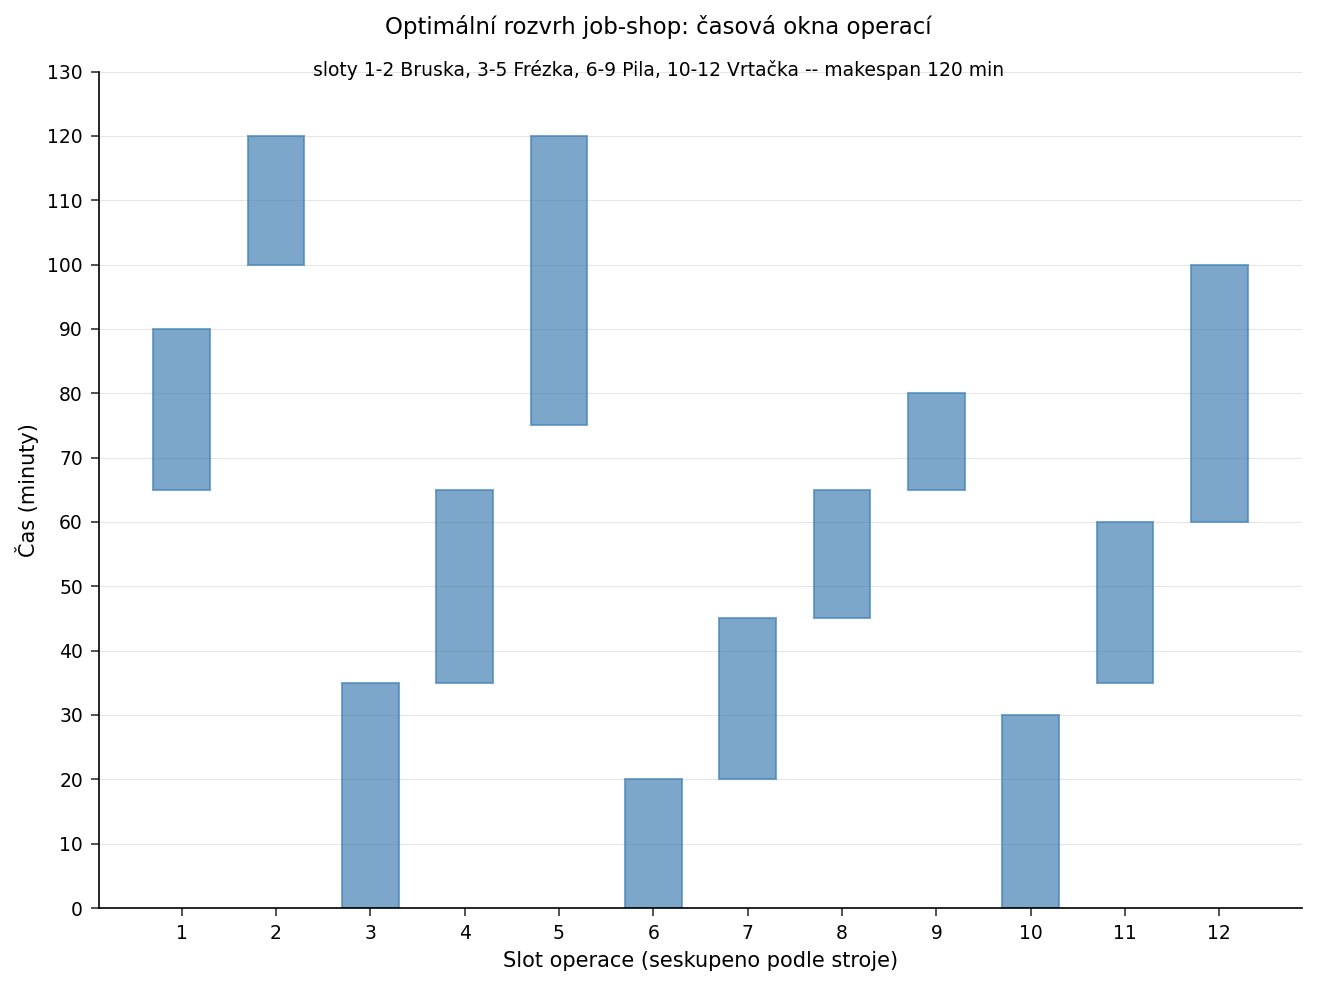

In [4]:
data ganttdata;
    NASTAVIT schedule;
    slot + 1;
SPUSTIT;

PROCEDURA TISK data=ganttdata noobs;
    NÁZEV "Rozvrh podle slotů (pořadí slotů odpovídá grafu níže)";
    PROMĚNNÁ slot mname jobname START FINISH;
    ŠTÍTEK slot="Slot" mname="Stroj" jobname="Díl" START="Začátek" FINISH="Konec";
SPUSTIT;

PROCEDURA SGPLOT data=ganttdata noautolegend;
    NÁZEV "Optimální rozvrh job-shop: časová okna operací";
    title2 "sloty 1-2 Bruska, 3-5 Frézka, 6-9 Pila, 10-12 Vrtačka -- makespan 120 min";
    highlow x=slot HIGH=FINISH LOW=START / type=bar barwidth=0.65
            fillattrs=(color=steel) LINEATTRS=(color=navy);
    XAXIS ŠTÍTEK="Slot operace (seskupeno podle stroje)" integer
          VALUES=(1 TO 12 PODLE 1);
    YAXIS ŠTÍTEK="Čas (minuty)" grid VALUES=(0 TO 130 PODLE 10);
SPUSTIT;
NÁZEV;

## Interpretace výsledků

- **Optimalita.** MILP řešitel vrátil `Solution Status = Optimal` s `Objective Value = 120`, takže **120 minut je prokazatelně nejkratší možný makespan** pro tuto instanci — žádný rozvrh nemůže skončit dříve. Tento certifikát je právě to, co vám formulace matematického programování přináší oproti pouhému prohledávání přípustnosti.

- **Rozvrh dodržuje každé omezení.** Při čtení tabulky podle strojů se žádné dvě operace na témže stroji nepřekrývají (např. na stroji Pila: Hřídel 0–20, Konzola 20–45, Skříň 45–65, Příruba 65–80) a každý díl běží v technologickém pořadí (např. Skříň: Vrtačka 0–30, poté Pila 45–65, poté Frézka 75–120). Graf s plovoucími sloupci ukazuje totéž: v pásmu slotů každého stroje se časová okna skládají bez kolize.

- **Co určuje délku rozvrhu.** Dvě operace končí přesně v minutě 120 — broušení dílu Konzola (slot 2) a frézování dílu Skříň (slot 5). Obě se dotýkají makespanu, takže stroje Bruska a Frézka leží na kritické cestě; další zkrácení makespanu by vyžadovalo změnu samotné instance (rychlejší operace, další stroj nebo uvolněnou precedenci), nikoli pouhé přeuspořádání.

- **Jak to škáluje.** Formulace přirozeně roste: přidejte stroj jako další hodnotu `machine`, přidejte díly jako další řádky `jobshop` nebo modelujte časy uvolnění a termíny omezením `s[o]` a přidáním omezení termínů. Umožnění, aby stroj zpracovával několik úloh najednou (kapacita >1), nahradí párovou disjunkci omezením kumulativního zdroje. Tentýž OPTMODEL MILP pak zvládne bohatší dílenská pravidla beze změny řešitele.